# Stroke Prediction

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler, MinMaxScaler

## Part 1: Dataset Loading and Exploration

In [26]:
# Load the dataset
df=pd.read_csv('healthcare-dataset-stroke-data.csv')
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [27]:
# Display first five records
print(df.head())
# Display last five records
print(df.tail())
# Display dataset dimensions
print(df.shape)
# Display data types
print(df.dtypes)

      id  gender   age  hypertension  heart_disease ever_married  \
0   9046    Male  67.0             0              1          Yes   
1  51676  Female  61.0             0              0          Yes   
2  31112    Male  80.0             0              1          Yes   
3  60182  Female  49.0             0              0          Yes   
4   1665  Female  79.0             1              0          Yes   

       work_type Residence_type  avg_glucose_level   bmi   smoking_status  \
0        Private          Urban             228.69  36.6  formerly smoked   
1  Self-employed          Rural             202.21   NaN     never smoked   
2        Private          Rural             105.92  32.5     never smoked   
3        Private          Urban             171.23  34.4           smokes   
4  Self-employed          Rural             174.12  24.0     never smoked   

   stroke  
0       1  
1       1  
2       1  
3       1  
4       1  
         id  gender   age  hypertension  heart_disease e

In [29]:
# Summary statistics
print(df.describe())
num=df.select_dtypes(include=np.number).columns.tolist()
cat=df.select_dtypes(exclude=np.number).columns.tolist()
print("Numerical:",num)
print("Categorical:",cat)
print("Target:",'stroke')

                 id          age  hypertension  heart_disease  \
count   5110.000000  5110.000000   5110.000000    5110.000000   
mean   36517.829354    43.226614      0.097456       0.054012   
std    21161.721625    22.612647      0.296607       0.226063   
min       67.000000     0.080000      0.000000       0.000000   
25%    17741.250000    25.000000      0.000000       0.000000   
50%    36932.000000    45.000000      0.000000       0.000000   
75%    54682.000000    61.000000      0.000000       0.000000   
max    72940.000000    82.000000      1.000000       1.000000   

       avg_glucose_level          bmi       stroke  
count        5110.000000  4909.000000  5110.000000  
mean          106.147677    28.893237     0.048728  
std            45.283560     7.854067     0.215320  
min            55.120000    10.300000     0.000000  
25%            77.245000    23.500000     0.000000  
50%            91.885000    28.100000     0.000000  
75%           114.090000    33.100000     0

## Part 2: Data Quality Assessment

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64
Duplicates: 0
gender ['Male' 'Female' 'Other']
ever_married ['Yes' 'No']
work_type ['Private' 'Self-employed' 'Govt_job' 'children' 'Never_worked']
Residence_type ['Urban' 'Rural']
smoking_status ['formerly smoked' 'never smoked' 'smokes' 'Unknown']
id 0
age 0
hypertension 498
heart_disease 276
avg_glucose_level 627
bmi 110
stroke 249


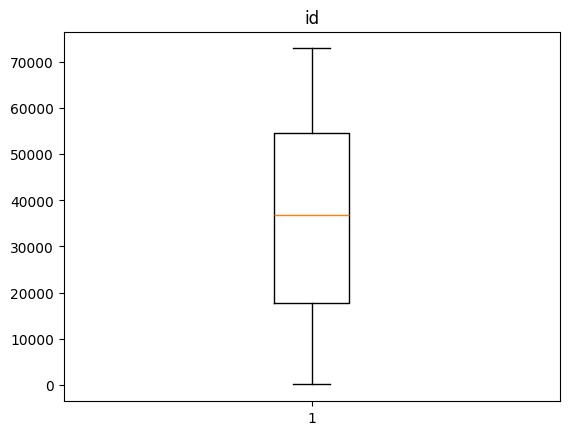

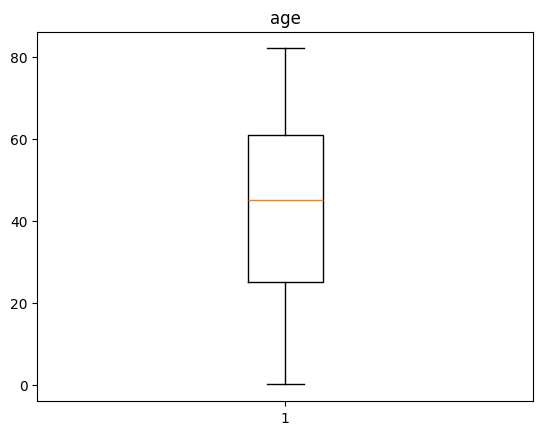

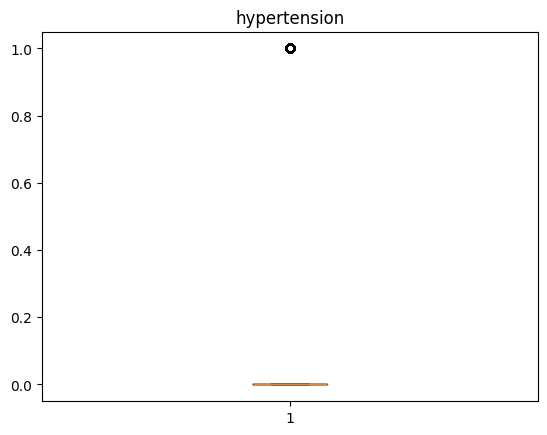

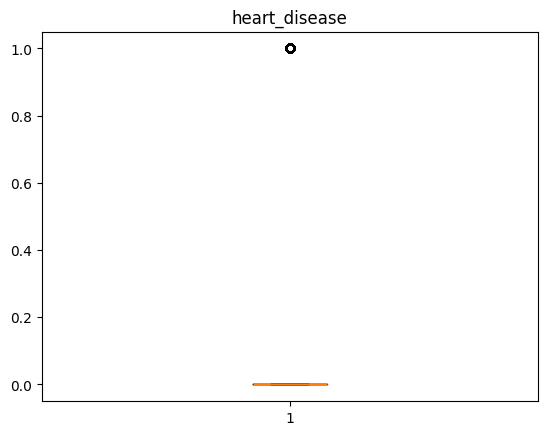

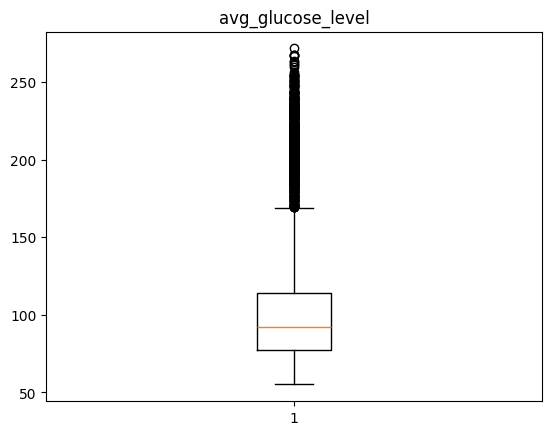

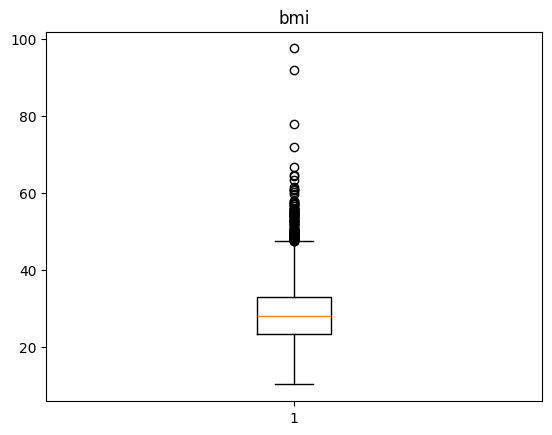

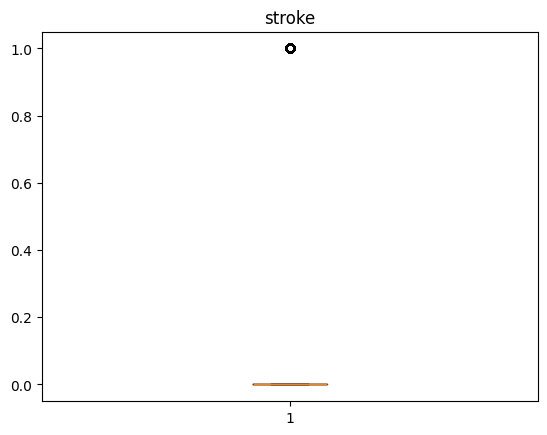

In [ ]:
# Check for missing values
print(df.isnull().sum())

# Count duplicate records
print("Duplicates:",df.duplicated().sum())

# Clean categorical values
for c in cat:
    print(c, df[c].unique())
for c in num:
    q1,q3=df[c].quantile([0.25,0.75]);iqr=q3-q1
    lo,hi=q1-1.5*iqr,q3+1.5*iqr
    print(c,((df[c]<lo)|(df[c]>hi)).sum())
    plt.figure();plt.boxplot(df[c].dropna());plt.title(c)
plt.show()

## Part 3: Data Preprocessing

In [ ]:
# Remove duplicate records
df=df.drop_duplicates()

# Fill missing BMI values using median
df['bmi']=df['bmi'].fillna(df['bmi'].median())

# Clean categorical values
for c in cat:
    df[c]=df[c].astype(str).str.strip().str.lower()
    df[c]=df[c].fillna(df[c].mode()[0])
    
# Handle outliers using the IQR method
numerical_features = [c for c in num if c != "stroke" and c != "hypertension" and c != "heart_disease"]

for c in numerical_features:
    q1,q3=df[c].quantile([0.25,0.75]);iqr=q3-q1
    lo,hi=q1-1.5*iqr,q3+1.5*iqr
    df[c]=df[c].clip(lo,hi)

In [32]:
# Save cleaned dataset (after completing Part 3)
# Create a copy of the cleaned dataset
cleaned_df = df.copy()
cleaned_df.to_csv("stroke_dataset_cleaned.csv", index=False)
print("Saved: stroke_dataset_cleaned.csv")
cleaned_df.head()

Saved: stroke_dataset_cleaned.csv


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,male,67.0,0,1,yes,private,urban,169.3575,36.6,formerly smoked,1
1,51676,female,61.0,0,0,yes,self-employed,rural,169.3575,28.1,never smoked,1
2,31112,male,80.0,0,1,yes,private,rural,105.9200,32.5,never smoked,1
3,60182,female,49.0,0,0,yes,private,urban,169.3575,34.4,smokes,1
4,1665,female,79.0,1,0,yes,self-employed,rural,169.3575,24.0,never smoked,1


## Part 4: Feature Engineering

In [ ]:
before=df.shape[1]
# Create BMI category feature
df['bmi_category']=pd.cut(df['bmi'],bins=[0,18.5,25,30,100],labels=['Underweight','Normal','Overweight','Obese'])

# Create age group feature
df['age_group']=pd.cut(df['age'],bins=[0,18,40,60,120],labels=['Child','Young Adult','Adult','Senior'])

# Create hypertension risk score feature
df['hypertension_risk_score']=df['hypertension']+df['heart_disease']
print(before,df.shape[1])
print(df[['bmi_category','age_group','hypertension_risk_score']].head())

12 15
  bmi_category age_group  hypertension_risk_score
0        Obese    Senior                        1
1   Overweight    Senior                        0
2        Obese    Senior                        1
3        Obese     Adult                        0
4       Normal    Senior                        1


In [34]:
# Save feature engineered dataset (after Part 4)
# Create a copy of the feature engineered dataset
feature_engineered_df = df.copy()
feature_engineered_df.to_csv("stroke_dataset_feature_engineered.csv", index=False)
print("Saved: stroke_dataset_feature_engineered.csv")
feature_engineered_df.head()

Saved: stroke_dataset_feature_engineered.csv


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,bmi_category,age_group,hypertension_risk_score
0,9046,male,67.0,0,1,yes,private,urban,169.3575,36.6,formerly smoked,1,Obese,Senior,1
1,51676,female,61.0,0,0,yes,self-employed,rural,169.3575,28.1,never smoked,1,Overweight,Senior,0
2,31112,male,80.0,0,1,yes,private,rural,105.9200,32.5,never smoked,1,Obese,Senior,1
3,60182,female,49.0,0,0,yes,private,urban,169.3575,34.4,smokes,1,Obese,Adult,0
4,1665,female,79.0,1,0,yes,self-employed,rural,169.3575,24.0,never smoked,1,Normal,Senior,1


## Part 5: Feature Handling

In [ ]:
# Separate input features (X)
X=feature_engineered_df.drop('stroke',axis=1)

# Separate target variable (y)
y=feature_engineered_df['stroke']
cat=X.select_dtypes(include='object').columns.tolist()+X.select_dtypes(include='category').columns.tolist()
num=X.select_dtypes(include=np.number).columns.tolist()

# Initialize Label Encoder
le=LabelEncoder()
X_le=X.copy()

# Clean categorical values
for c in cat:
    if X_le[c].dtype!='category' and X_le[c].nunique()==2:
        X_le[c]=le.fit_transform(X_le[c].astype(str))

# Apply One-Hot Encoding
X_enc=pd.get_dummies(X_le,columns=[c for c in cat if X_le[c].dtype==object or str(X_le[c].dtype)=='category'],drop_first=True)

# Initialize StandardScaler
std=StandardScaler()

# Initialize MinMaxScaler
mm=MinMaxScaler()
X_std=pd.DataFrame(std.fit_transform(X_enc),columns=X_enc.columns)
X_mm=pd.DataFrame(mm.fit_transform(X_enc),columns=X_enc.columns)
print(X_enc.head())
print(X_std.describe().loc[['mean','std']].head())
print(X_mm.describe().loc[['min','max']].head())
print("Final features:",X_enc.columns.tolist())

      id   age  hypertension  heart_disease  ever_married  Residence_type  \
0   9046  67.0             0              1             1               1   
1  51676  61.0             0              0             1               0   
2  31112  80.0             0              1             1               0   
3  60182  49.0             0              0             1               1   
4   1665  79.0             1              0             1               0   

   avg_glucose_level   bmi  hypertension_risk_score  gender_male  ...  \
0           169.3575  36.6                        1         True  ...   
1           169.3575  28.1                        0        False  ...   
2           105.9200  32.5                        1         True  ...   
3           169.3575  34.4                        0        False  ...   
4           169.3575  24.0                        1        False  ...   

   work_type_self-employed  smoking_status_never smoked  \
0                    False             

In [ ]:
# Save model-ready dataset after encoding
# Save the encoded dataset for model training
model_ready = X_enc.copy()
model_ready['stroke'] = y.reset_index(drop=True)
model_ready.to_csv("stroke_dataset_model_ready.csv", index=False)
print("Saved: stroke_dataset_model_ready.csv")

## Part 6: Documentation

- Missing BMI values were imputed using the median.
- Duplicate rows were removed.
- Categorical values were standardized to lowercase.
- Outliers were clipped using the IQR rule.
- New features:
  1. BMI Category
  2. Age Group
  3. Hypertension Risk Score
- Label Encoding was used for binary categories.
- One-Hot Encoding was used for multi-class categories.
- StandardScaler and MinMaxScaler were compared.
- The encoded feature matrix is recommended for model training.
